In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

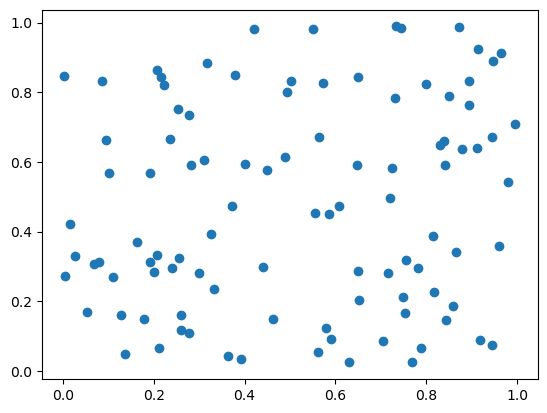

In [24]:
from koala.pointsets import uniform

points = uniform(100)

plt.scatter(*points.T)

In [ ]:
from koala.pointsets import move_all_points, move_point


def test_move_point():
    rng = np.random.default_rng(1234)

    points2 = uniform(100, 2, rng)
    points3 = uniform(100, 3, rng)

    move_point(points2, 1, 0.01, 0.01, resolution=10)
    move_point(points3, 1, 0.01, 0.01, resolution=10)


def test_move_all_points():
    rng = np.random.default_rng(1234)

    points2 = uniform(100, 2, rng)
    points3 = uniform(100, 3, rng)

    move_all_points(points2, 0.01, 0.01, resolution=10)
    move_all_points(points3, 0.01, 0.01, resolution=10)


test_move_point()
test_move_all_points()

In [72]:
p2 = uniform(500, 2)

In [146]:
sigma = 0.09
kappa = 0.03

%time _ = move_point(p2, 0, sigma, kappa, beta=1, resolution=20)

CPU times: user 9.25 ms, sys: 988 μs, total: 10.2 ms
Wall time: 9.39 ms


In [74]:
sigma = 1 / 40 + 0.0001
kappa = sigma * 1

L = 20
# make grid
pos = np.linspace(0, 1, L, endpoint=False)
pos += 0.5 * (pos[1] - pos[0])
p = np.reshape(np.meshgrid(pos, pos), [2, -1]).T

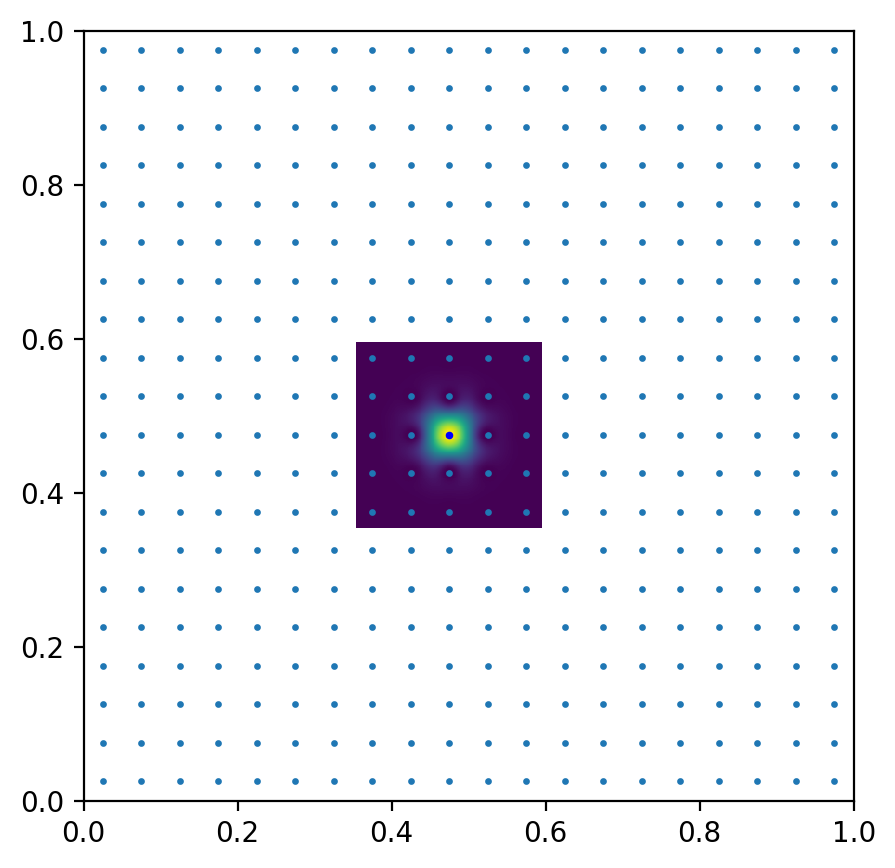

np.int64(189)

In [113]:
d_from_center = p - 0.5

central_point = np.argmin(np.sum((p - 0.5) ** 2, axis=1))
_ = move_point(
    p,
    central_point,
    sigma,
    1 / np.sqrt(np.pi * len(p)),
    beta=1,
    debug_plot=True,
    resolution=200,
)

central_point

100%|██████████| 10/10 [00:13<00:00,  1.37s/it]


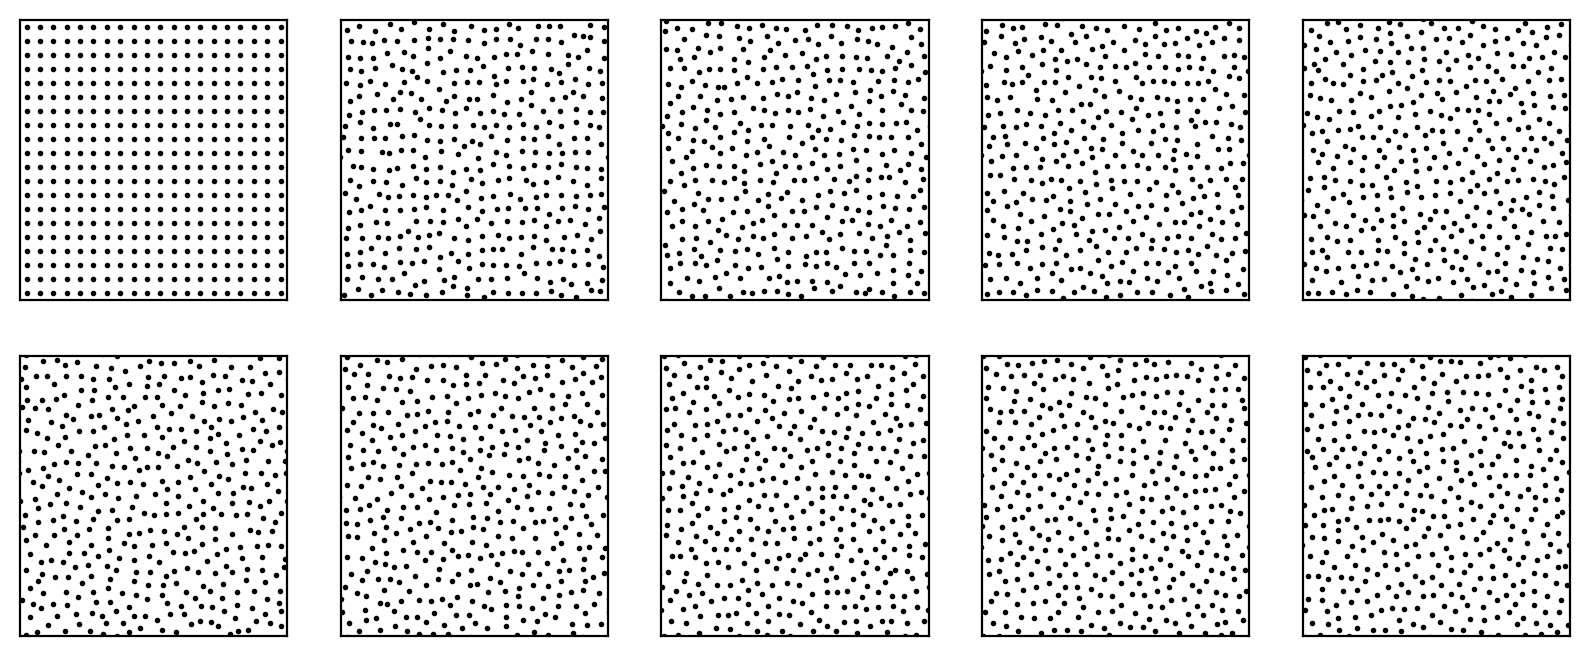

In [ ]:
n_steps = 10

fig, ax = plt.subplots(n_steps // 5, 5, figsize=(10, 2 * n_steps // 5), dpi=200)
ax = ax.flatten()

sigma = 0.02
kappa = 0.1

p_new = p.copy()
for a in tqdm(ax):
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    s = 1
    a.scatter(*p_new.T, s=s, c="k")
    a.scatter(*(p_new + (0, 1)).T, s=s, c="k")
    a.scatter(*(p_new + (1, 0)).T, s=s, c="k")
    a.scatter(*(p_new + (0, -1)).T, s=s, c="k")
    a.scatter(*(p_new + (-1, 0)).T, s=s, c="k")

    p_new = move_all_points(p_new, sigma, kappa, beta=4, resolution=30)

In [86]:
sigma
kappa

%time _ = move_all_points(p_new, sigma, kappa, beta=5, resolution=3)

CPU times: user 541 ms, sys: 2.37 ms, total: 544 ms
Wall time: 552 ms
